# Extraction visuals for the report

Run this AFTER the wrist-tiebreak pass and manual review are done, so these visuals reflect the final, disambiguated dataset rather than the first-pass extraction.

Three things: real pose overlays on actual video frames for a sample of classes, confidence distributions across the whole dataset, and a per-class summary chart. Saved to /workspace/outputs/report_visuals/ as both PNG (300 DPI) and PDF.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, "/workspace/badminton-honours-project/pipeline")
from pose_extraction_utils import extract_one_clip, draw_bbox_overlay, draw_pose_overlay, COCO_SKELETON

OUT_DIR = "/workspace/outputs/report_visuals"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


### load the final extraction log (post-disambiguation)

In [2]:
log = pd.read_csv("/workspace/data/extraction_log.csv")
if "excluded" not in log.columns:
    log["excluded"] = False
usable = log[~log["excluded"]].reset_index(drop=True)

print(f"usable clips: {len(usable)}")
print(f"excluded: {log['excluded'].sum()}")
print(f"still flagged ambiguous (ratio>0.6): {(usable['track_area_ratio'] > 0.6).sum()}")


usable clips: 7814
excluded: 4
still flagged ambiguous (ratio>0.6): 0


### Figure 1 - real pose overlays on actual frames, one per class

Not the synthetic scatter-plot skeletons from the augmentation QC - these reload the actual video and re-run detection+pose on one representative clip per class, so what's shown is the real frame with the real detected skeleton on top.

In [3]:
from ultralytics import YOLO
from mmpose.apis import init_model

CHECKPOINT_DIR = "/workspace/checkpoints"
pose_config = glob.glob(os.path.join(CHECKPOINT_DIR, "rtmpose-m*coco-256x192*.py"))[0]
pose_checkpoint = glob.glob(os.path.join(CHECKPOINT_DIR, "rtmpose-m*256x192*.pth"))[0]

detector = YOLO("yolov8m.pt")
pose_model = init_model(pose_config, pose_checkpoint, device="cuda:0")


/workspace/venv/lib/python3.10/site-packages/mmengine/utils/package_utils.py:48: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Loads checkpoint by local backend from path: /workspace/checkpoints/rtmpose-m_simcc-coco_pt-aic-coco_420e-256x192-d8dd5ca4_20230127.pth


/tmp/ipykernel_90267/2310679476.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_rows = usable.groupby("class_name").apply(lambda g: g.sample(1, random_state=11)).reset_index(drop=True)


00_Short Serve                 mean_conf=0.63
01_Cross Court Flight          mean_conf=0.65
02_Lift                        mean_conf=0.70
03_Tap Smash                   mean_conf=0.72
04_Block                       mean_conf=0.74
05_Drop Shot                   mean_conf=0.62
06_Push Shot                   mean_conf=0.56
07_Transitional Slice          mean_conf=0.70
08_Cut                         mean_conf=0.60
09_Rush Shot                   mean_conf=0.60
10_Defensive Clear             mean_conf=0.66
11_Defensive Drive             mean_conf=0.67
12_Clear                       mean_conf=0.63
13_Long Serve                  mean_conf=0.61
14_Smash                       mean_conf=0.74
15_Flat Shot                   mean_conf=0.67
16_Rear Court Flat Drive       mean_conf=0.70
17_Short Flat Shot             mean_conf=0.66


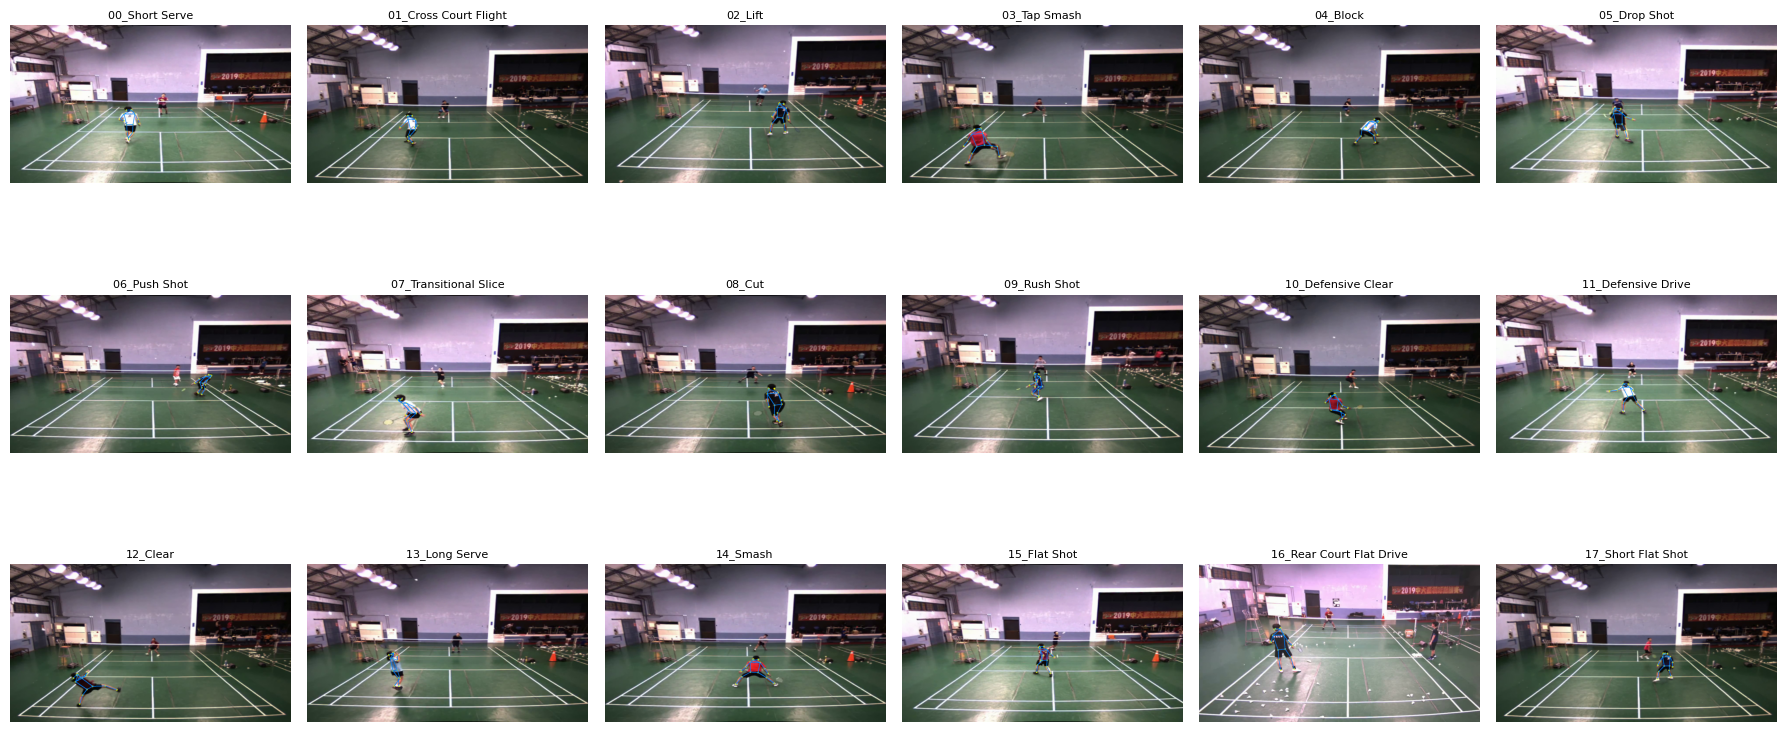

In [4]:
class_names = sorted(usable["class_name"].unique())
sample_rows = usable.groupby("class_name").apply(lambda g: g.sample(1, random_state=11)).reset_index(drop=True)

n_cols = 6
n_rows = -(-len(sample_rows) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for ax in axes[len(sample_rows):]:
    ax.axis("off")

for i, row in sample_rows.iterrows():
    video_path = os.path.join("/workspace/data/raw", row["filepath"])
    keypoints_seq, meta, debug = extract_one_clip(
        video_path, detector, pose_model, n_frames=30, return_debug=True
    )
    mid = len(debug["valid_frames"]) // 2
    mid_frame_idx = debug["valid_frames"][mid]
    frame = debug["all_frames"][mid_frame_idx]
    mid_seq_idx = 15
    pose_img = draw_pose_overlay(frame, keypoints_seq[mid_seq_idx])
    pose_img_rgb = cv2.cvtColor(pose_img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(pose_img_rgb)
    axes[i].set_title(row["class_name"], fontsize=8)
    axes[i].axis("off")

    print(f"{row['class_name']:30s} mean_conf={meta['mean_confidence']:.2f}")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pose_overlay_examples_all_classes.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/pose_overlay_examples_all_classes.pdf", bbox_inches="tight")
plt.show()


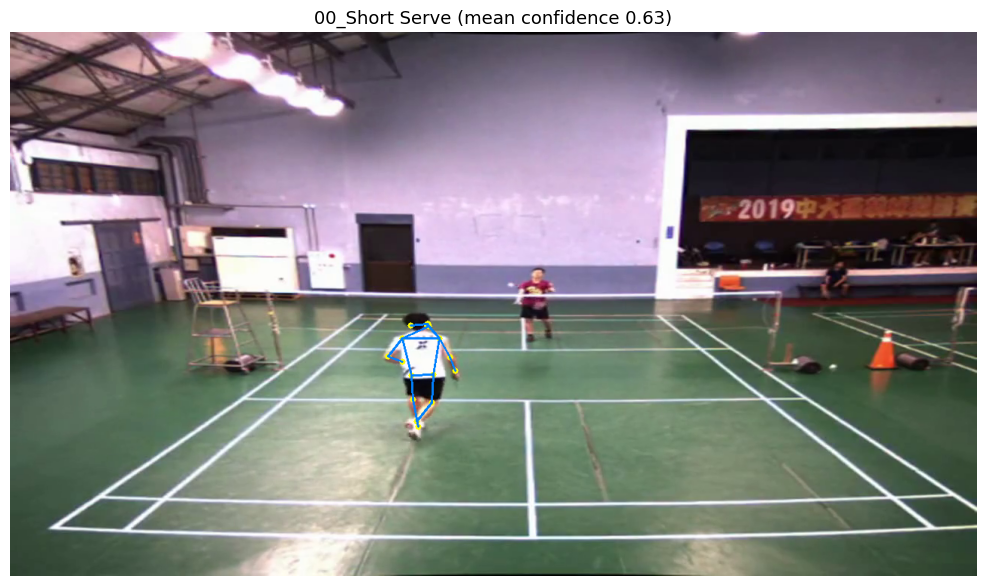

00_Short Serve: mean_confidence=0.631  saved to /workspace/outputs/report_visuals/pose_overlay_00_Short_Serve.png


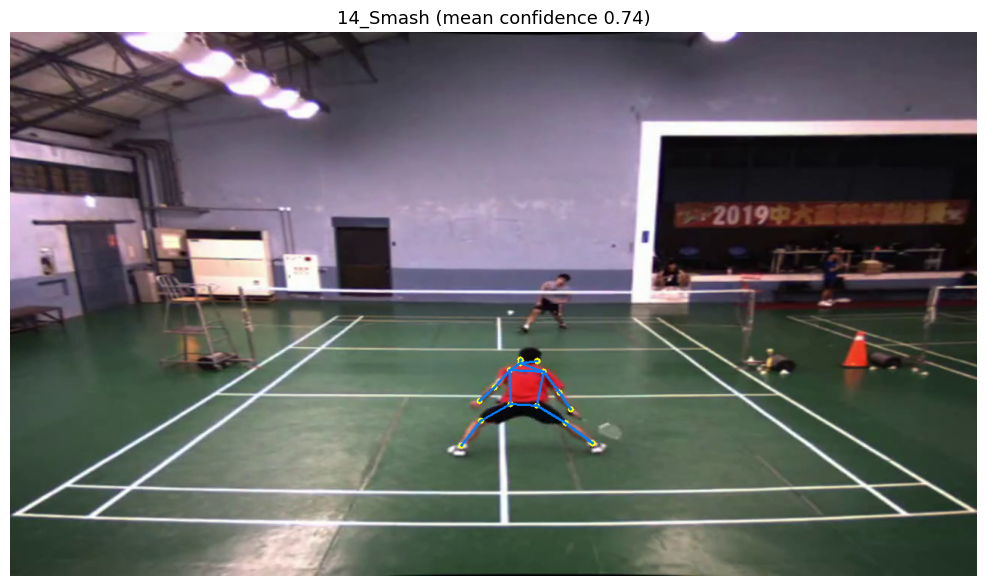

14_Smash: mean_confidence=0.740  saved to /workspace/outputs/report_visuals/pose_overlay_14_Smash.png


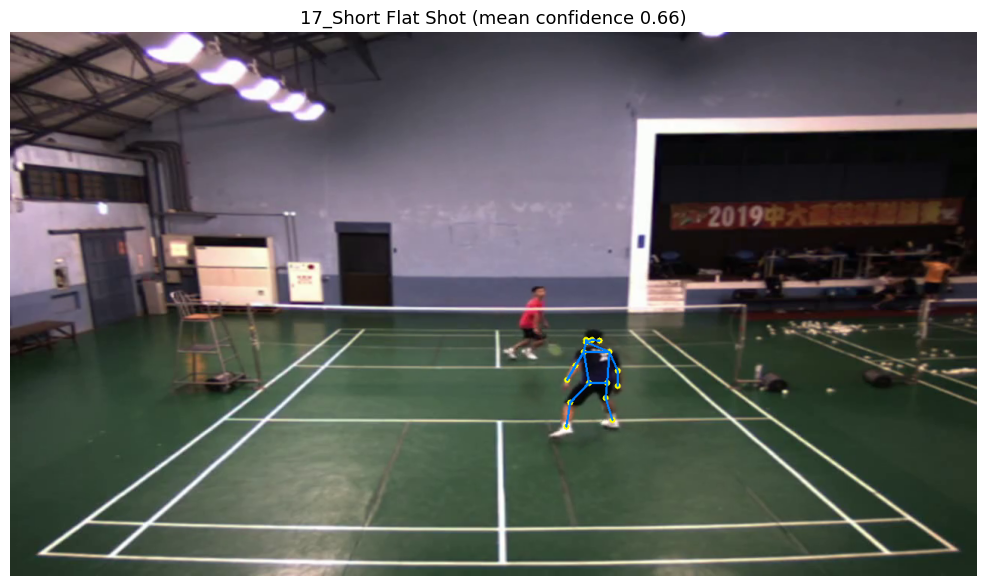

17_Short Flat Shot: mean_confidence=0.657  saved to /workspace/outputs/report_visuals/pose_overlay_17_Short_Flat_Shot.png


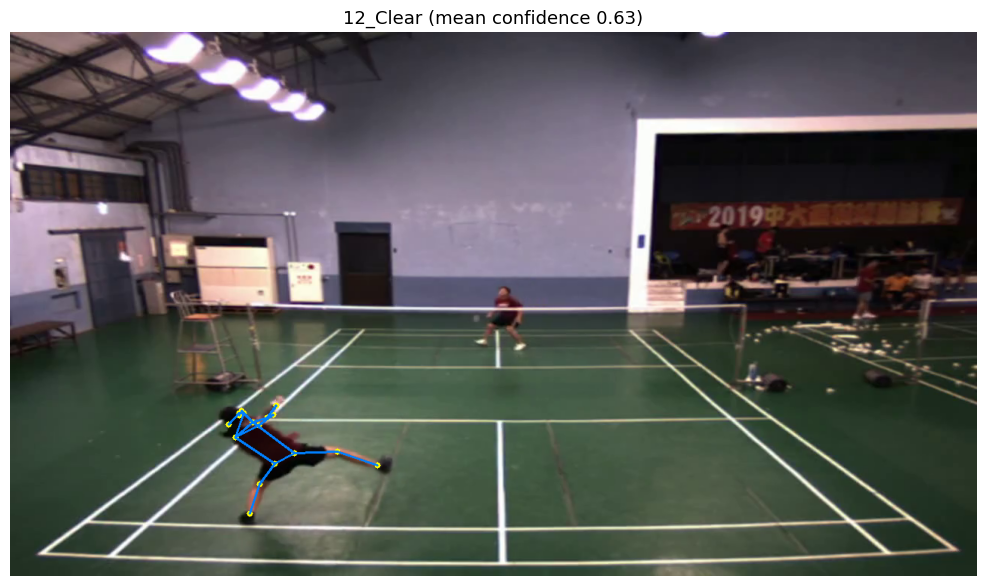

12_Clear: mean_confidence=0.635  saved to /workspace/outputs/report_visuals/pose_overlay_12_Clear.png


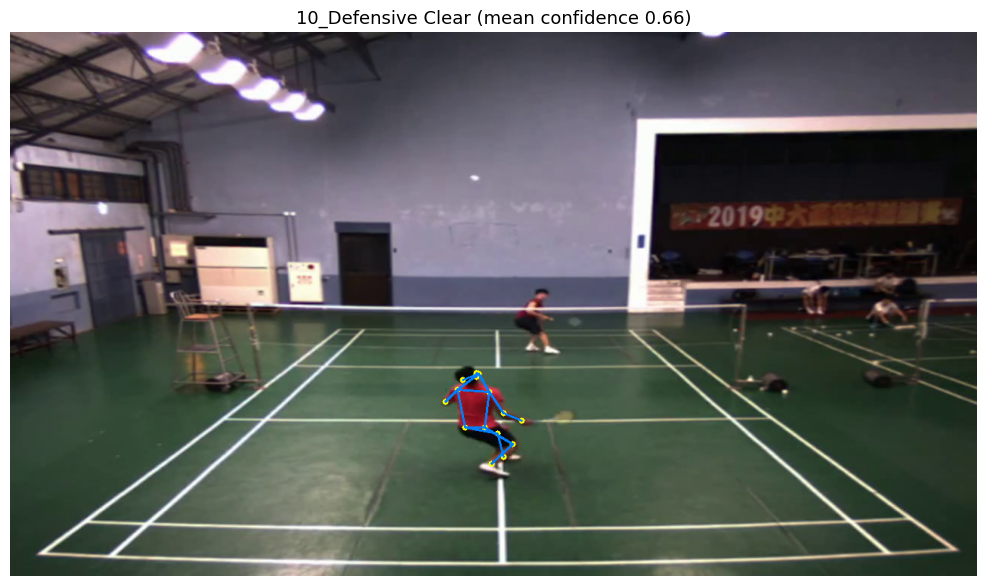

10_Defensive Clear: mean_confidence=0.657  saved to /workspace/outputs/report_visuals/pose_overlay_10_Defensive_Clear.png


In [8]:
SELECTED_CLASSES = [
    '00_Short Serve',
    '14_Smash',
    '17_Short Flat Shot',
    '12_Clear',
    '10_Defensive Clear',
]  # <- edit this list to pick different classes

for class_name in SELECTED_CLASSES:
    row = sample_rows[sample_rows['class_name'] == class_name].iloc[0]
    video_path = os.path.join('/workspace/data/raw', row['filepath'])

    keypoints_seq, meta, debug = extract_one_clip(
        video_path, detector, pose_model, n_frames=30, return_debug=True
    )
    mid = len(debug['valid_frames']) // 2
    mid_frame_idx = debug['valid_frames'][mid]
    frame = debug['all_frames'][mid_frame_idx]
    pose_img = draw_pose_overlay(frame, keypoints_seq[15])
    pose_img_rgb = cv2.cvtColor(pose_img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(pose_img_rgb)
    ax.set_title(f'{class_name} (mean confidence {meta["mean_confidence"]:.2f})', fontsize=13)
    ax.axis('off')
    plt.tight_layout()

    safe_name = class_name.replace(' ', '_')
    plt.savefig(f'{OUT_DIR}/pose_overlay_{safe_name}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{OUT_DIR}/pose_overlay_{safe_name}.pdf', bbox_inches='tight')
    plt.show()

    print(f'{class_name}: mean_confidence={meta["mean_confidence"]:.3f}  saved to {OUT_DIR}/pose_overlay_{safe_name}.png')

### Figure 2 - confidence distribution across the whole dataset

Histogram of per-clip mean confidence, all 18 classes pooled - shows the overall quality picture in one figure.

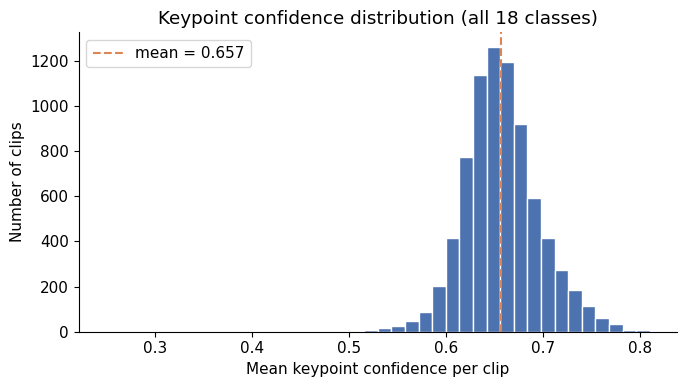

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(usable["mean_confidence"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(usable["mean_confidence"].mean(), color="#DD8452", linestyle="--",
           label=f"mean = {usable['mean_confidence'].mean():.3f}")
ax.set_xlabel("Mean keypoint confidence per clip")
ax.set_ylabel("Number of clips")
ax.set_title("Keypoint confidence distribution (all 18 classes)")
ax.legend()
plt.tight_layout()

plt.savefig(f"{OUT_DIR}/confidence_distribution.png", dpi=300)
plt.savefig(f"{OUT_DIR}/confidence_distribution.pdf")
plt.show()


### Figure 3 - per-class confidence, sorted

Horizontal bar chart, mean confidence per class - shows which shot types the pipeline handles best/worst, useful context for interpreting model results later.

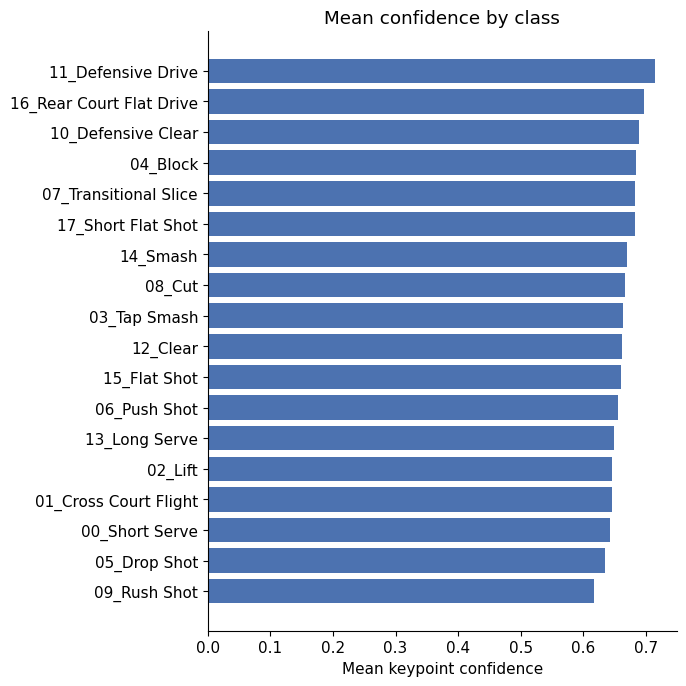

In [6]:
class_conf = usable.groupby("class_name")["mean_confidence"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(class_conf.index, class_conf.values, color="#4C72B0")
ax.set_xlabel("Mean keypoint confidence")
ax.set_title("Mean confidence by class")
plt.tight_layout()

plt.savefig(f"{OUT_DIR}/confidence_by_class.png", dpi=300)
plt.savefig(f"{OUT_DIR}/confidence_by_class.pdf")
plt.show()


### Figure 4 - selection method breakdown

How each clip's primary player ended up chosen - area+motion (the vast majority), wrist tiebreak (the harder cases), or manual review (the genuinely ambiguous residual). Useful single-paragraph evidence for the data-quality section of the report.

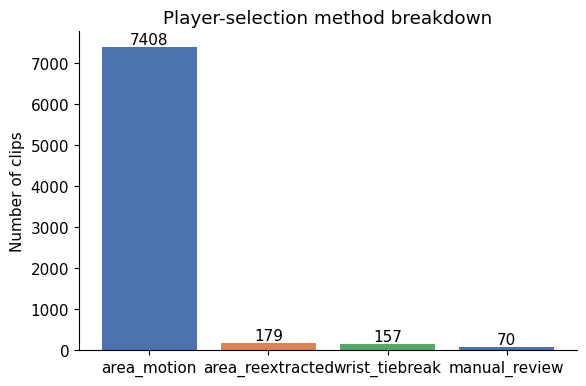

selection_method
area_motion         7408
area_reextracted     179
wrist_tiebreak       157
manual_review         70
Name: count, dtype: int64

excluded (real hitter never tracked): 4


In [7]:
method_counts = usable["selection_method"].fillna("area_motion").value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(method_counts.index, method_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Number of clips")
ax.set_title("Player-selection method breakdown")
for i, v in enumerate(method_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()

plt.savefig(f"{OUT_DIR}/selection_method_breakdown.png", dpi=300)
plt.savefig(f"{OUT_DIR}/selection_method_breakdown.pdf")
plt.show()

print(method_counts)
print(f"\nexcluded (real hitter never tracked): {log['excluded'].sum()}")


---

All four figures saved to /workspace/outputs/report_visuals/ as PNG (300 DPI) and PDF. Commit the PNGs to the repo if you want them versioned - hold off on the PDFs, same reasoning as before, they're large binary files better kept local/Overleaf-only.